# Functional enrichment of genomic regions

In the previous notebooks, we successfully integrated ATAC-seq, ChIP-seq, RNA-seq, and WGBS data to classify thousands of genomic regions into distinct biological states (e.g., *Active Promoters*, *Lost Enhancers*, *Silenced*). However, assigning a biological label to a genomic coordinate is only half the battle. To truly understand the developmental biology of our system (E11.5 to E15.5), we need to ask: **What biological pathways do these specific regulatory regions actually control?**

In this notebook, we will perform **Functional Enrichment Analysis**. Unlike standard RNA-seq analysis (which relies on isolated lists of genes), we will use **GREAT** (Genomic Regions Enrichment of Annotations Tool) to mathematically map our physical, non-coding regulatory coordinates directly to biological functions.

## Learning objectives

- Use the `rGREAT` package to map cis-regulatory elements directly to biological pathways.
- Generate Volcano plots and region-gene association graphs to diagnose enrichment significance.
- Use the `simplifyEnrichment` package to collapse hundreds of highly redundant Gene Ontology (GO) terms into clustered functional groups.
- Interpret the actual biological meaning behind the pathways enriched in our *Active Promoters*.

## Environment setup & data loading

Because we are mathematically mapping raw genomic coordinates to biological meaning, we need to load massive **Annotation Databases** that contain the physical coordinates and pathway annotations for our specific organism (Mouse).

### Loading the required libraries

In [1]:
suppressPackageStartupMessages(suppressWarnings({
  library(dplyr)

  # Core analytical packages for region enrichment and clustering
  library(magick)
  library(rGREAT)
  library(simplifyEnrichment)
  library(flexclust)

  # Transcript Database containing the exact physical coordinates 
  # for every known gene in the Mouse `mm10` genome
  library(TxDb.Mmusculus.UCSC.mm10.knownGene)

  # Organism-level database that links mouse gene IDs to human-readable GO terms
  library(org.Mm.eg.db)
}))

### Importing the multi-omics overlap data

We will start by loading the final, fully-annotated `GRanges` object that we generated in the previous notebooks. This object contains all of our ATAC-seq peaks, cross-referenced against RNA-seq, and tagged with their final biological regulatory category.

In [2]:
# Load the annotated overlap object
overlap <- readRDS("output/overlap_multiomics_state.rds")

# Contingency table to view the categories we can test
table(overlap$Multiomics_State)


             Active    Active Promoters           Dec. Acc.    Gained Enhancers 
                248                  99                 580                  18 
          Inc. Acc.         Incongruent      Lost Enhancers           Repressed 
                516                 166                   9                 126 
Repressed Promoters            Silenced 
                  5                 166 

### Exploring the "Silenced" Regions

We just saw that our **Active Promoters** are strongly enriched for synapse formation and neurodevelopment. However, as cells differentiate, they must also permanently repress genes from earlier progenitor stages or alternative cell lineages.

To investigate this repression, we will analyze the **`Silenced`** category. As we saw in our contingency table, this cluster contains a robust **166 regions**, providing excellent statistical power for the `rGREAT` algorithm. More importantly, these regions share a highly specific multi-omics signature: a severe decrease in chromatin accessibility (ATAC-seq) and active acetylation (H3K27ac), a massive gain in Polycomb-mediated repression (H3K27me3), and a clear downregulation in target gene expression (RNA-seq).

Let's quickly re-run our enrichment pipeline on these 166 regions to see exactly what biological pathways the developing brain is actively shutting down!

## Genomic region enrichment via rGREAT

Now that we have selected our target category, we need to extract those specific physical coordinates from our massive overlapping dataset and feed them into the **GREAT** algorithm.

### Subsetting the Genomic Ranges

First, we use standard R indexing to extract only the 99 peaks classified as `Active Promoters`.

In [3]:
# Extract only the Active Promoters using the cleaner subset() method
gr <- subset(overlap, Multiomics_State == "Active Promoters")

# Drop empty chromosome levels using the official Bioconductor method
seqlevels(gr) <- seqlevelsInUse(gr)

# Print the isolated object to verify we have exactly 99 ranges
gr

GRanges object with 99 ranges and 111 metadata columns:
            seqnames              ranges strand |        ATAC_annotation
               <Rle>           <IRanges>  <Rle> |            <character>
     peak_1     chr1     3670547-3672665      * |       Promoter (<=1kb)
    peak_14     chr1     9298449-9300284      * |       Promoter (<=1kb)
    peak_69     chr1   25228208-25229714      * |       Promoter (<=1kb)
    peak_70     chr1   25504015-25505076      * | Exon (ENSMUST0000014..
    peak_83     chr1   34578812-34580363      * |       Promoter (<=1kb)
        ...      ...                 ...    ... .                    ...
  peak_1902     chr2 178175169-178175887      * |       Promoter (<=1kb)
  peak_1922     chr2 181134082-181135787      * |       Promoter (<=1kb)
  peak_1923     chr2 181156149-181157204      * |       Promoter (<=1kb)
  peak_1925     chr2 181313272-181314836      * |       Promoter (<=1kb)
  peak_1930     chr2 181714476-181715931      * |       Promoter (<=

Notice that we re-assign the `seqlevels`. As discussed in [a previous notebook](./04-genomic_overlap_matrices.ipynb), when we subset a `GRanges` object, it remembers *all* the original chromosomes, even the ones that now have 0 peaks. Dropping these "empty" chromosomes is a critical sanitization step to prevent downstream algorithms from crashing or miscalculating genome background sizes.

### Executing the GREAT algorithm

Now we pass our isolated coordinates directly to the `great()` function.

Unlike standard RNA-seq enrichment that relies on isolated gene names, GREAT maps **physical genome space**. Because our ATAC-seq peaks are mostly non-coding regulatory elements (like distal enhancers), they rarely sit directly *inside* the genes they regulate.

To solve this, GREAT calculates a **"regulatory domain"** for every known gene in the mouse genome by starting at the Transcription Start Site (TSS):

1. **Basal Domain:** It first assigns a core regulatory region immediately surrounding the TSS (typically 5kb upstream and 1kb downstream).
2. **Distal Extension:** It then extends this domain outward in both directions along the chromosome until it hits the regulatory domain of the nearest neighboring gene (up to a massive maximum of 1,000 kb!).

GREAT then maps our 99 ATAC-seq peaks to see which of these extended regulatory domains they physically fall into. This allows us to accurately link distal regulatory DNA to the specific biological pathways they control.

In [4]:
# Run the Genomic Regions Enrichment of Annotations Tool
res <- great(
  gr = gr, 
  gene_sets = "BP",   # testing against the **Biological Process** GO
  tss_source = "mm10" # use the Mouse mm10 database to locate the TSS
)

* TSS source: TxDb.

* check whether TxDb package 'TxDb.Mmusculus.UCSC.mm10.knownGene' is installed.

* gene ID type in the extended TSS is 'Entrez Gene ID'.

* restrict chromosomes to 'chr1, chr2, chr3, chr4, chr5, chr6, chr7, chr8, chr9, chr10,
    chr11, chr12, chr13, chr14, chr15, chr16, chr17, chr18, chr19, chrX, chrY, chrM'.

* 20598/24515 protein-coding genes left.

* update seqinfo to the selected chromosomes.

* TSS extension mode is 'basalPlusExt'.

* construct the basal domains by extending 5000bp to upstream and 1000bp to downsteram of TSS.

* calculate distances to neighbour regions.

* extend to both sides until reaching the neighbour genes or to the maximal extension.

* use GO:BP ontology with 14957 gene sets (source: org.Mm.eg.db).

* check gene ID type in `gene_sets` and in `extended_tss`.

* use whole genome as background.

* remove excluded regions from background.

* overlap `gr` to background regions (based on midpoint).

* in total 99 `gr`.

* overlap extended TS

*Notice that it says `* restrict chromosomes to chr1, chr2...`. `rGREAT` is actually smart enough to automatically filter out weird unplaced contigs based on its internal TSS database. However, applying `seqlevelsInUse()` immediately after subsetting is still a crucial Bioconductor habit to learn, as many other downstream algorithms will crash or miscalculate background statistics if they detect empty chromosomes sitting in our object's metadata.*

### QA/QC: verifying the GREAT mapping

Before we jump into the visualizations, simply printing the `res` object provides a critical Quality Control check. 

It tells us exactly how many of our 99 physical ATAC-seq peaks successfully intersected with the mathematical regulatory domain of a known gene. If the vast majority of our peaks mapped successfully, we have the green light to proceed to pathway visualization.

In [5]:
# Print a summary of the GREAT object
print(res)

99 regions are associated to 113 genes' extended TSSs.
  TSS source: TxDb.Mmusculus.UCSC.mm10.knownGene
  Genome: mm10
  OrgDb: org.Mm.eg.db
  Gene sets: BP
  Background: whole genome excluding gaps
Mode: Basal plus extension
  Proximal: 5000 bp upstream, 1000 bp downstream,
  plus Distal: up to 1000000 bp


## Visualizing and interpreting enrichment results

Now that the GREAT algorithm has successfully mapped our ATAC-seq peaks to biological pathways, we need to extract biological meaning from the statistics. We will explore and refine our results using four distinct approaches.

### Statistical significance: the Volcano plot

Because `rGREAT` is built specifically for genomic regions, its native `plotVolcano()` function operates a little differently than a standard RNA-seq volcano plot. Instead of plotting individual genes, each dot on this plot represents an entire **Biological Pathway**.

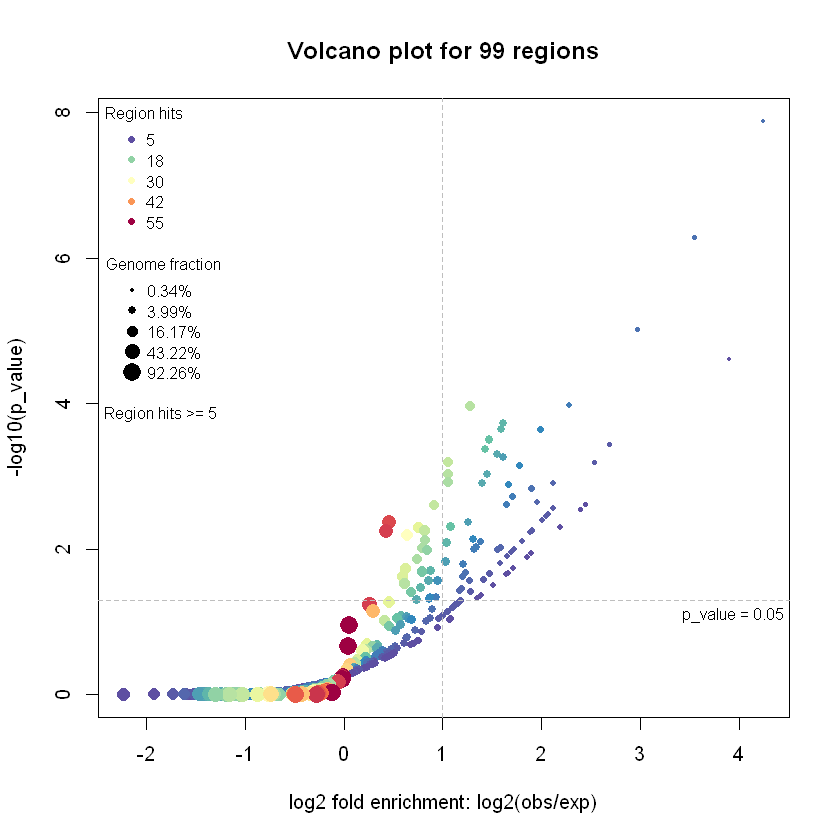

In [6]:
# Generate a Volcano plot directly from the GREAT results object.
# GREAT actually runs two mathematical tests simultaneously, so this will 
# plot the Fold Enrichment vs P-value for BOTH the Binomial test (genomic space) 
# and the Hypergeometric test (gene count).
plotVolcano(res)

Each dot represents an entire **Biological Pathway**. To find the most meaningful networks, we must read the plot across three dimensions:

* **Location (Significance & Enrichment):** The true "winners" fly into the **top-right quadrant** (above the $p=0.05$ significance threshold and $>2\times$ fold enrichment).
* **Dot Size (Pathway Size):** Massive dark red dots near the bottom have many hits (~55 peaks), but because they are huge, generic pathways, hitting them is expected by pure random chance.
* **Color (Absolute Hits):** The small blue dots in the top-right only have ~5 peak hits. However, because those pathways are physically tiny (small dot size), getting even 5 hits is incredibly rare. These represent highly specific, tightly coordinated biological networks.

### Physical mapping: region-gene associations

Now that we know which biological pathways are enriched, we need to inspect the physical mapping that generated those statistics. How exactly did GREAT assign our 99 ATAC-seq peaks to target genes? Did they map to local promoters, or long-range distal regions?

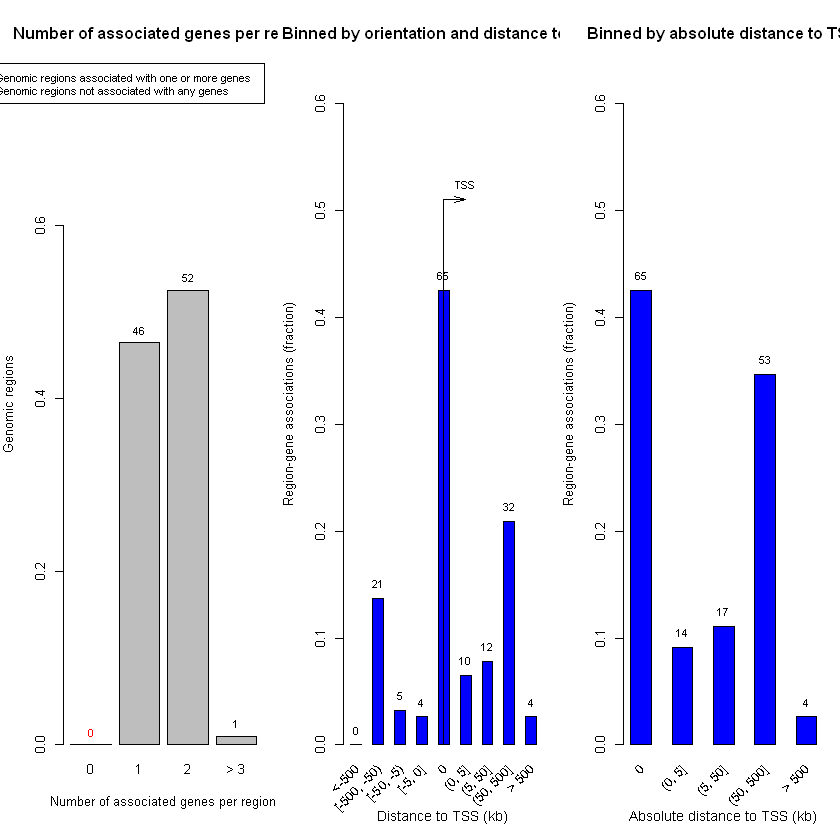

In [7]:
# options(repr.plot.width = 12, repr.plot.height = 6)

# Generate three diagnostic bar plots showing exactly how many genes 
# each ATAC-seq peak was mapped to, and the physical distance to the TSS.
plotRegionGeneAssociations(res)

These three plots perfectly validate the multi-omics classification pipeline we built in our previous notebook:

* **Plot 1 (Left - Genes per Region):** We see 0 red hits, meaning 100% of our peaks successfully mapped to at least one gene! Most peaks map to 1 or 2 genes (because GREAT's "extension" rule often hits immediate neighbors).
* **Plots 2 & 3 (Distance to TSS):** Because we specifically isolated the `Active Promoters` cluster for this analysis, we biologically expect these peaks to sit directly on top of genes. The massive spike exactly at `0 kb` physically proves that our multi-omics logic successfully isolated true promoters!

_(Note: The smaller bars further out at 50-500kb simply reflect that genes are packed tightly together, and one gene's promoter might physically overlap with the extended regulatory domain of a distant neighbor)._

### Exploring the raw data

While the Volcano plot gives us a great high-level view of our enriched pathways, we now need to dig deeper into the actual biology. To do this, we must extract the raw data so we can systematically sort the pathways by significance and identify the exact names of the target genes our ATAC-seq peaks hit.

_While `rGREAT` does come with a built-in interactive dashboard (`shinyReport(res)`), **Shiny applications do not play nicely with Jupyter Notebooks.** Launching a Shiny app will hijack the R kernel. In many Jupyter environments, attempting to stop the Shiny app will completely crash the R session, forcing to restart the kernel and run all previous cells from the beginning._

In [8]:
# (Optional) Launch the interactive GREAT dashboard. 
# Warning: This will freeze the Jupyter kernel until manually interrupted!

# shinyReport(res)

Instead of relying on a clunky dashboard, we can extract the raw mathematical results into a standard R dataframe.

In [9]:
# Extract the full enrichment table into a standard dataframe
tb <- getEnrichmentTable(res)

# View the top 6 most significantly enriched pathways
print(head(tb))

           id                                                   description
1  GO:0099509 regulation of presynaptic cytosolic calcium ion concentration
3  GO:0070050                                   neuron cellular homeostasis
4  GO:0051480             regulation of cytosolic calcium ion concentration
5  GO:1901385          regulation of voltage-gated calcium channel activity
10 GO:0019226                                 transmission of nerve impulse
11 GO:0098655                     monoatomic cation transmembrane transport
   genome_fraction observed_region_hits fold_enrichment      p_value
1      0.004255723                    8       18.988097 1.305671e-08
3      0.006914366                    8       11.686983 5.113900e-07
4      0.010302148                    8        7.843809 9.447899e-06
5      0.003398694                    5       14.860134 2.486941e-05
10     0.018695488                    9        4.862622 1.062248e-04
11     0.087208298                   21        2.43235

### Downstream filtering of biological pathways

Because `getEnrichmentTable()` returns a standard R dataframe, we are no longer trapped inside a "black box" bioinformatics tool. We can use the exact same `dplyr` data wrangling skills we learned in previous notebooks to aggressively mine this table for biological meaning.

Here are three highly practical examples of how we can filter our pathway results both mathematically and biologically.

In [10]:
# 1. Filter Mathematically: Keep only highly significant pathways (FDR < 0.05)
sig_pathways <- tb %>% filter(p_adjust < 0.05)

# 2. Filter by Evidence: Keep pathways hit by at least 5 of our ATAC peaks
# (GREAT outputs specific columns tracking region hits)
robust_pathways <- sig_pathways %>% filter(observed_region_hits >= 5)

# 3. Filter Biologically: Search for specific pathway keywords (e.g., 'calcium' or 'synap')
calcium_pathways <- tb %>% filter(grepl("calcium|synap", description, ignore.case = TRUE))

# View our biologically targeted pathways
print(head(calcium_pathways))

          id                                                   description
1 GO:0099509 regulation of presynaptic cytosolic calcium ion concentration
2 GO:0051480             regulation of cytosolic calcium ion concentration
3 GO:1901385          regulation of voltage-gated calcium channel activity
4 GO:0006874                         intracellular calcium ion homeostasis
5 GO:2000300                     regulation of synaptic vesicle exocytosis
6 GO:0070588                           calcium ion transmembrane transport
  genome_fraction observed_region_hits fold_enrichment      p_value
1     0.004255723                    8       18.988097 1.305671e-08
2     0.010302148                    8        7.843809 9.447899e-06
3     0.003398694                    5       14.860134 2.486941e-05
4     0.025446934                   10        3.969441 2.254245e-04
5     0.009403625                    6        6.444968 3.672851e-04
6     0.039552568                   12        3.064583 5.528246e-04

### Clustering redundant pathways (semantic similarity)

As we just saw in our filtered data table above, the Gene Ontology (GO) database is notoriously redundant. Because our active promoters are enriched for calcium signaling, the database returned *regulation of presynaptic cytosolic calcium*, *intracellular calcium ion homeostasis*, and *calcium ion transmembrane transport* as completely separate pathways.

If we don't mathematically compress this data, we will be forced to manually read through hundreds of nearly identical terms. To make sense of this massive, repetitive list, we can use the `simplifyEnrichment` package. This algorithm calculates the **Semantic Similarity** between all of our significant GO terms (how closely related they are in the biological tree) and physically clusters them into clean, high-level functional blocks.

You haven't provided value for `ont`, guess it as `BP`.

relations: is_a, part_of, regulates, negatively_regulates, positively_regulates

IC_method: IC_annotation

term_sim_method: Sim_XGraSM_2013

IC_method: IC_annotation

Cluster 41 terms by 'binary_cut'...
 4 clusters, used 0.2807021 secs.

Perform keywords enrichment for 4 GO lists...



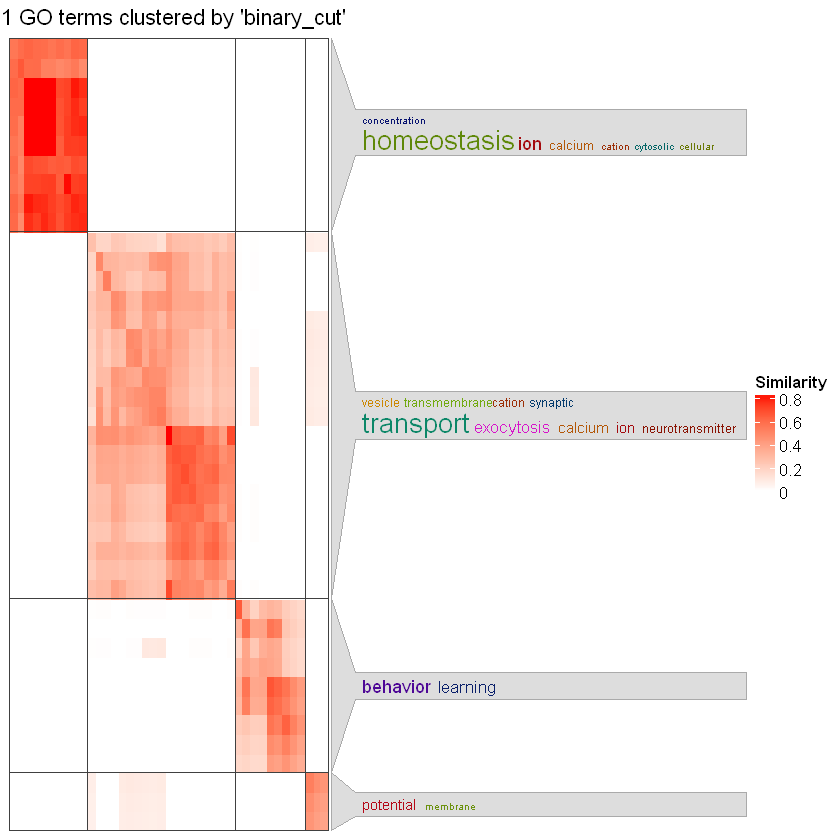

In [11]:
# Extract the exact GO IDs for our statistically significant pathways
sig_go_ids <- tb$id[tb$p_adjust < 0.05]

# Calculate the semantic similarity matrix and cluster the redundant terms
# (Note: This might take a minute as it mathematically compares hundreds of GO terms!)
cl <- simplifyGO(sig_go_ids)

This visualization condenses the repetitive results. The red diagonal matrix mathematically groups all the 41 GO terms into distinct clusters based on their similarity. Instead of forcing us to read dozens of nearly identical pathway names, the algorithm generates clean word clouds summarizing the overarching biological function of each block: calcium homeostasis, synaptic transport, membrane potential, and learning behavior.

You haven't provided value for `ont`, guess it as `BP`.

term_sim_method: Sim_XGraSM_2013

IC_method: IC_annotation

Cluster 41 terms by 'binary_cut'...
 4 clusters, used 0.2557878 secs.

Perform keywords enrichment for 4 GO lists...



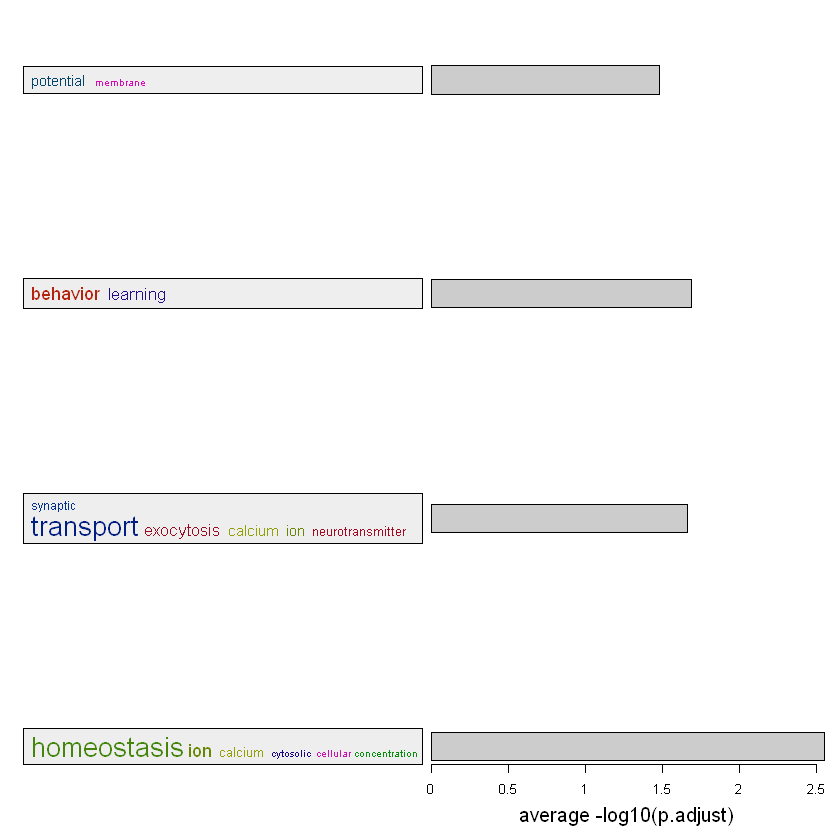

In [12]:
# Generate a heatmap summarizing our high-level biological clusters
summarizeGO(
  go_id = sig_go_ids, 
  -log10(tb$p_adjust[tb$p_adjust < 0.05]), 
  axis_label = "average -log10(p.adjust)"
)

This bar chart summarizes our data by showing the average statistical significance of each functional block. The "calcium homeostasis" cluster is by far the most statistically robust group (the longest bar), indicating that calcium signaling is a primary molecular driver in these cells.

Biologically, this makes perfect sense; E11.5 to E15.5 is a critical embryonic window for neural development, involving rapid neuronal differentiation and synapse formation. The fact that our mathematically isolated *Active Promoters* are overwhelmingly driving ion transport, synaptic transmission, and learning circuitry perfectly aligns with early neural maturation. Our multi-omics integration successfully captured the exact developmental window where the embryonic brain begins to wire itself.

### Exploring the "Silenced" regions

We just saw that our **Active Promoters** are strongly enriched for synapse formation and neurodevelopment. However, as cells differentiate, they must also permanently repress genes from earlier progenitor stages or alternative cell lineages.

To investigate this repression, we will analyze the **`Silenced`** category. As we saw in our contingency table, this cluster contains a robust **166 regions**, providing excellent statistical power for the `rGREAT` algorithm. More importantly, these regions share a highly specific multi-omics signature: a severe decrease in chromatin accessibility (ATAC-seq) and active acetylation (H3K27ac), a massive gain in Polycomb-mediated repression (H3K27me3), and a clear downregulation in target gene expression (RNA-seq).

Let's quickly re-run our enrichment pipeline on these 166 regions to see exactly what biological pathways the developing brain is actively shutting down.

In [13]:
gr_silenced <- subset(overlap, Multiomics_State == "Silenced")
seqlevels(gr_silenced) <- seqlevelsInUse(gr_silenced)

res_silenced <- great(
  gr = gr_silenced, 
  gene_sets = "BP", 
  tss_source = "mm10"
)

* TSS source: TxDb.

* extended_tss is already cached, directly use it.

* use GO:BP ontology with 14957 gene sets (source: org.Mm.eg.db).

* check gene ID type in `gene_sets` and in `extended_tss`.

* use whole genome as background.

* remove excluded regions from background.

* overlap `gr` to background regions (based on midpoint).

* in total 166 `gr`.

* overlap extended TSS to background regions.

* check which genes are in the gene sets.

* only take gene sets with size >= 5.

* in total 9288 gene sets.

* overlap `gr` to every extended TSS.

* perform binomial test for each biological term.



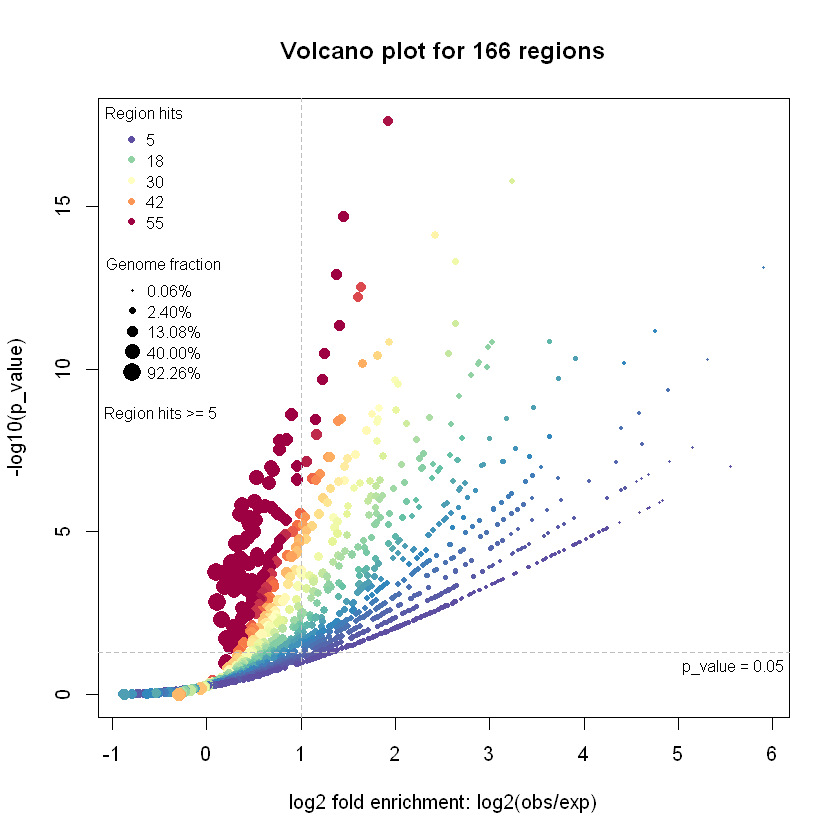

In [14]:
# Generate the Volcano plot for the silenced regions
plotVolcano(res_silenced)

Notice how different this Volcano plot is compared to our `Active Promoters`. The significance scores reach massively higher ($p < 10^{-17}$), and there is an absolute swarm of pathways flying into the top-right quadrant.

While a differentiating cell only needs to activate a small, highly targeted set of pathways to become a neuron, it must simultaneously repress *massive, heavily populated* gene networks associated with every other possible cell fate. Because Polycomb (H3K27me3) coordinates the shutdown of these massive networks all at once, the statistical enrichment for repression is mathematically off the charts.

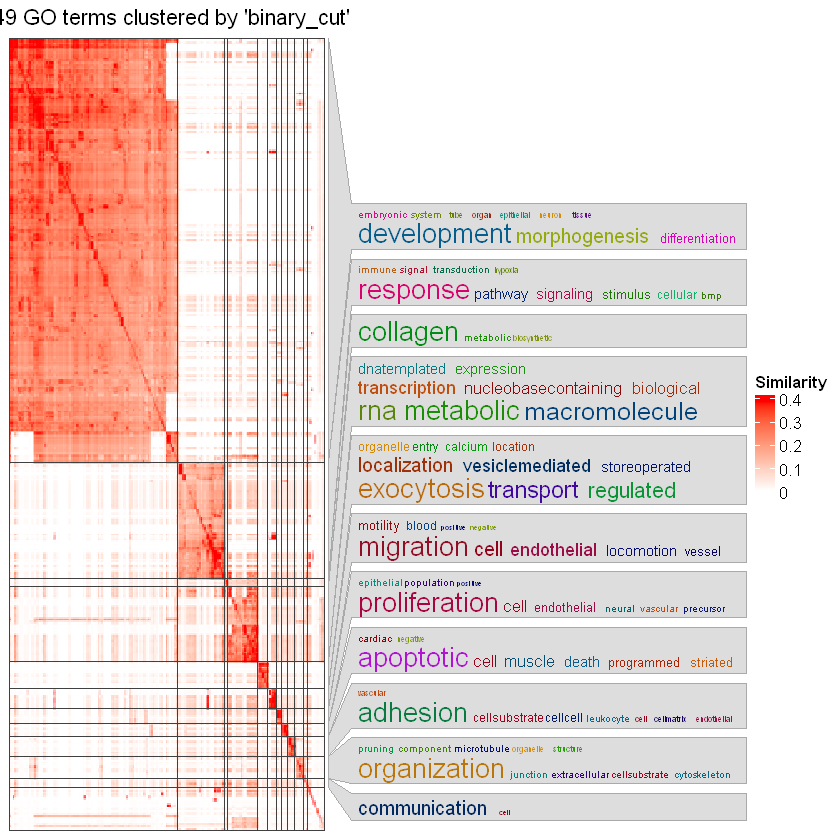

In [15]:
tb_silenced <- getEnrichmentTable(res_silenced)
sig_go_ids_silenced <- tb_silenced$id[tb_silenced$p_adjust < 0.05]

cl_silenced <- suppressMessages(
  simplifyGO(sig_go_ids_silenced))

While our `Active Promoters` enriched for just 41 pathways, the `Silenced` regions enriched for **hundreds**. 

The semantic similarity matrix above mathematically groups this massive list into distinct functional blocks. Looking closely at the word clouds on the right, we can see the algorithm successfully clustered terms related to **Collagen** (connective tissue), **Endothelial** (blood vessels), and **Striated Muscle**.

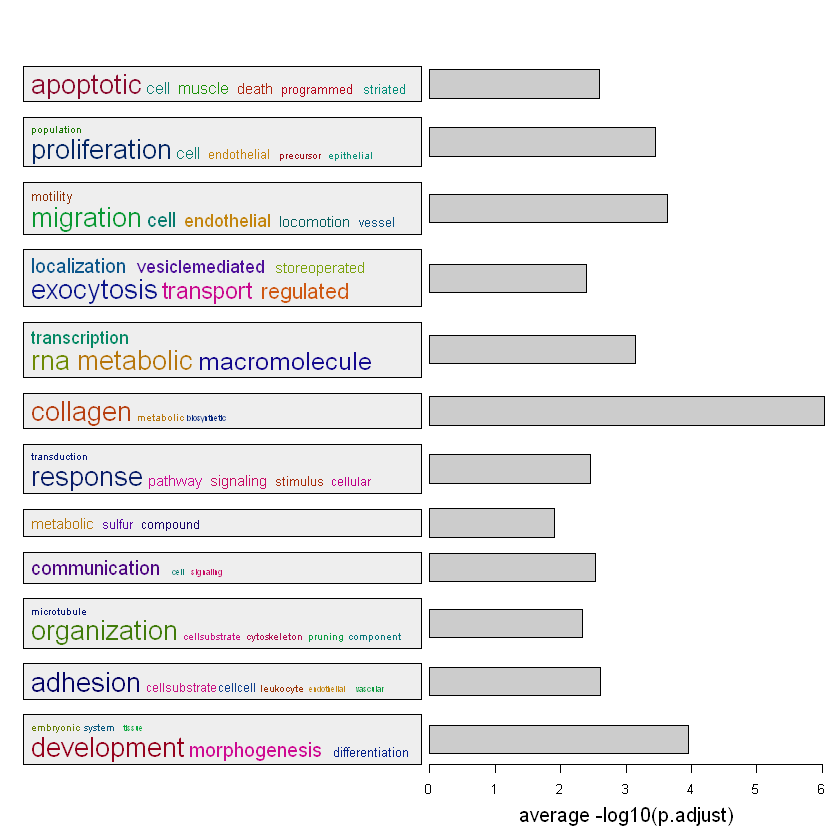

In [16]:
suppressMessages(
  summarizeGO(
    go_id = sig_go_ids_silenced, 
    -log10(tb_silenced$p_adjust[tb_silenced$p_adjust < 0.05]), 
    axis_label = "average -log10(p.adjust)"))

This bar chart highlights the average statistical significance of our repressed functional blocks. Notice that the significance scale is much higher than what we saw in the Active Promoters. The "collagen" (connective tissue) cluster is by far the most statistically *repressed* group, closely followed by general embryonic morphogenesis, endothelial cell migration, and cellular proliferation.

Biologically, this validates the E11.5 to E15.5 developmental timeline. As the embryonic brain rapidly develops and neurons terminally differentiate, the cells must make permanent fate decisions. While we saw our `Active Promoters` turning *on* synapses and calcium signaling, this plot reveals the exact opposite side of the development process. The developing neural tissue is actively and permanently crushing alternative mesoderm lineages—like collagen, endothelial cells, and striated muscle, using Polycomb-mediated silencing. 

Furthermore, the strong repression of the "proliferation" cluster perfectly aligns with the biology of early neurogenesis, as mature neurons must become post-mitotic and stop dividing. By mathematically integrating ATAC, ChIP, and RNA-seq, our multi-omics pipeline has successfully decoded the entire developmental decision-making process of the cell!